## open model

In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/model/Aomsin0308_model.h5")
print(model.name_scope)

In [ ]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.8 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.1
    Uninstalling packaging-24.1:
      Successfully uninstalled packaging-24.1


In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/model/Aomsin0308_model.keras")

In [ ]:
!pip install -q lib5c
!lib5c -v

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.2/16.2 MB 852.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.6 MB/s eta 0:00:00
lib5c version 0.6.1


In [ ]:
!tensorflowjs_converter --input_format=keras /content/drive/MyDrive/model/Aomsin0308_model.keras /tmp/tfjs_model

In [ ]:
ls -l /content/drive/MyDrive/model/Aomsin0308_model.h5

-rw------- 1 root root 800 Aug  3 13:58 /content/drive/MyDrive/model/Aomsin0308_model.h5


In [ ]:
loaded_model = keras.models.load_model("/content/drive/MyDrive/model/Aomsin0308_model.keras")
loaded_model.save("/content/drive/MyDrive/model/Aomsin1408_model.h5")

TypeError: cannot pickle 'module' object

In [ ]:
import tensorflowjs as tfjs

tfjs.converters.save_keras_model(loaded_model, "/content/drive/MyDrive/model/Aomsin1408_model")

TypeError: cannot pickle 'module' object

In [ ]:
!pip install --upgrade keras

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow import keras

In [ ]:
!pip uninstall tensorflow
!pip uninstall keras

In [ ]:
!pip install tensorflow==2.16.1
!pip install keras==3.0


In [ ]:
print(keras.__version__)
print(tf.__version__)

3.4.1
2.17.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PATH = '/content/drive/MyDrive/classify/'
test = '/content/drive/MyDrive/test/'

In [ ]:
file_names = os.listdir(PATH)
print(file_names)

['holybasil', 'kaffir lime leaves', 'lime', 'basil(โหระพา)', 'celery(ตั้งโอ๋)', 'coriander(ผักชี)', 'gourd(ตำลึง)', 'Mango yawns, lemon ho', 'turmeric(ขมิ้น)', 'ginger(ขิง)', 'chives leaves(ใบกุ๋ยช่าย)', 'galangal(ข่า)', ' cassia leaves(ใบขี้เหล็ก)', 'pandan leaf(ใบเตย)', 'climbing wattle(ชะอม)', 'lemon grass(ตะไคร้)', 'wild betel(ใบพลู)', 'spring onion(ต้นหอม)', 'finger root(กระชาย)', 'Bitter cucumber(มะระขี้นก)', 'project.h5', 'edit_model.keras', 'group1-shard1of3.bin', 'group1-shard2of3.bin', 'group1-shard3of3.bin', 'model.json']


In [ ]:
train_dir = os.path.join(PATH)
validation_dir = os.path.join(test)

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180)

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=False,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE,
                                                            label_mode="categorical")

Found 2499 files belonging to 20 classes.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=False,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE,
                                                                 label_mode="categorical")

Found 2000 files belonging to 20 classes.


In [ ]:
validation_dataset.class_names

[' cassia leaves(ใบขี้เหล็ก)',
 'Bitter cucumber(มะระขี้นก)',
 'Mango yawns, lemon ho',
 'basil(โหระพา)',
 'celery(ตั้งโอ๋)',
 'chives leaves(ใบกุ๋ยช่าย)',
 'climbing wattle(ชะอม)',
 'coriander(ผักชี)',
 'finger root(กระชาย)',
 'galangal(ข่า)',
 'ginger(ขิง)',
 'gourd(ตำลึง)',
 'holybasil',
 'kaffir lime leaves',
 'lemon grass(ตะไคร้)',
 'lime',
 'pandan leaf(ใบเตย)',
 'spring onion(ต้นหอม)',
 'turmeric(ขมิ้น)',
 'wild betel(ใบพลู)']

In [ ]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 51
Number of test batches: 12


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## data_augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
  #tf.keras.layers.RandomSaturation(3),
  # tf.keras.layers.RandomCrop(central_fraction=0.5),
])

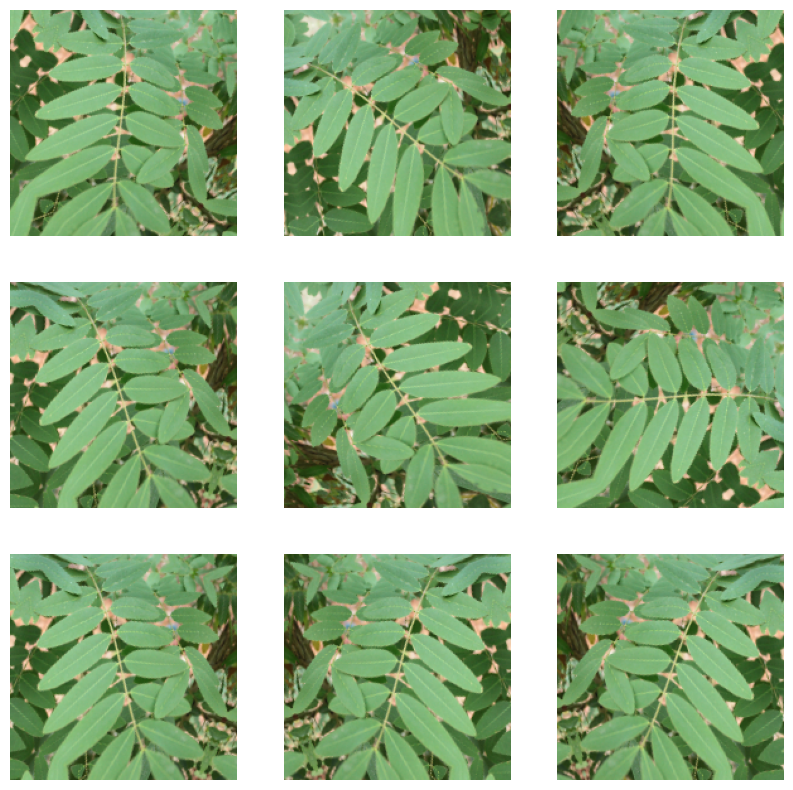

In [ ]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

<ipython-input-14-61cdd2a32e03>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 6, 6, 1280)


In [ ]:
base_model.trainable = False
# Let's take a look at the base model architecture
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 180, 180, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 90, 90, 32)     │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 90, 90, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 90, 90, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 90, 90, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 90, 90, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 90, 90, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 90, 90, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 90, 90, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 90, 90, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 90, 90, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 90, 90, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 91, 91, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 45, 45, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
prediction_layer = tf.keras.layers.Dense(20, activation="softmax")
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)
print(feature_batch_average.shape)

(32, 20)
(32, 1280)


In [ ]:
inputs = tf.keras.Input(shape=(180, 180, 3))
x1 = data_augmentation(inputs)
x2 = preprocess_input(x1)
x3 = base_model(x2, training=False)
x4 = global_average_layer(x3)
x5 = tf.keras.layers.Dropout(0.2)(x4)
outputs = prediction_layer(x5)
model = tf.keras.Model(inputs, outputs)
base_learning_rate = 0.0001
# model.compile(optimizer='your_optimizer', loss='binary_crossentropy', metrics=['accuracy'])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 6, 6, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │          25,620 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,283,604 (8.71 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
initial_epochs = 2
loss0, accuracy0 = model.evaluate(validation_dataset)
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

51/51 ━━━━━━━━━━━━━━━━━━━━ 565s 9s/step - accuracy: 0.0510 - loss: 3.3536
initial loss: 3.55
initial accuracy: 0.05


In [ ]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 664s 8s/step - accuracy: 0.0424 - loss: 3.8054 - val_accuracy: 0.0606 - val_loss: 3.5040
Epoch 2/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.0979 - loss: 3.0577 - val_accuracy: 0.1120 - val_loss: 3.0222


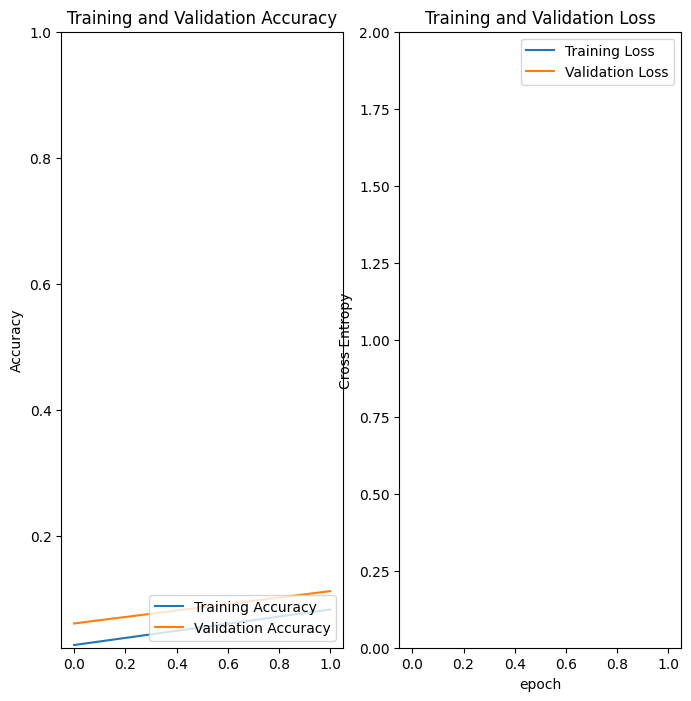

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,2.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## save

In [ ]:
import pickle
with open('/content/drive/MyDrive/model/history0308_model', 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

In [ ]:
model.save("/content/drive/MyDrive/model/Aomsin0308_model.h5")

In [ ]:
tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    /content/drive/MyDrive/model/Lab1 \
    /content/drive/MyDrive/model


SyntaxError: cannot assign to expression (<ipython-input-26-e48cdb593cea>, line 1)

In [ ]:
const saveResult = await model.save('localstorage://my-model-1');

SyntaxError: invalid syntax (<ipython-input-24-978addc73993>, line 1)

## open file

In [ ]:
model.save_weights("/content/drive/MyDrive/model/lab1_model.weights.h5")

In [ ]:
with open('/trainHistoryDict', "rb") as file_pi:
    history = pickle.load(file_pi)

## check accuracy

In [ ]:
loss, accuracy = model.evaluate(validation_dataset , verbose=2)
print('Restored model, accuracy: {:5.2f}%'.format(100 * accuracy))